# 1.1.2 单位、量纲与时间序列

## 学习目标与先修知识

- 保持时间序列（time series）的时刻与所追踪物质总量（tracked amount）逐项对应。
- 用单位检查表达式，区分总量与浓度（concentration）。
- 解释坐标单位改变前后不变的物理含义。

**先修知识**：[边界、状态与观测](01-边界状态与观测.ipynb)；乘除法、列表与配对循环。

## 具体问题

假设在 0、1、3、4 分钟记录某种物质为 10、8、5、5 U。U 是任意但固定的总量单位。这些都是手工选定的教学数值，不来自真实测量。

先把分钟改成秒。哪一项应该变：时刻的数字、总量的数字，还是两者都变？下面的列表始终按相同顺序配对。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
times_min = [0, 1, 3, 4]
amounts = [10, 8, 5, 5]
times_s = [60*t for t in times_min]
display(Markdown(show_table(['t / min', 't / s', '总量 / U'], zip(times_min, times_s, amounts))))

| t / min | t / s | 总量 / U |
| --- | --- | --- |
| 0 | 0 | 10 |
| 1 | 60 | 8 |
| 3 | 180 | 5 |
| 4 | 240 | 5 |

## 模型假设

我们只解释给定的观测（observation），没有假定物质怎样进入或离开。时刻之间的直线不是新增测量。量的表示由“数值 × 单位”组成：60 秒和 1 分钟数值不同，代表的持续时间相同。

量纲（dimension）说明一种量属于时间、长度、总量等哪一类；单位是具体尺度。分钟和秒都属于时间类。只有同类且换算到相容单位后才能直接相加。

浓度定义为总量 A 除以体积 V：同样的 6 U 分别放在 2 L 与 3 L 中，浓度是 3 与 2 U/L。只有体积固定时，浓度变化才与总量变化成同一比例。这里假设孔内混合均匀，所用体积是相同观察时刻的体积。

本教材用“所追踪物质总量（tracked amount）”描述模型（model）中追踪的量，U 表示所选的教学单位，后文简称“总量”。这不是 SI 基本量“物质的量（amount of substance）”的专用名称；后者按指定微观实体计量，SI 单位为 mol。使用具体数据时，须明确追踪的是质量、物质的量还是其他量，并采用相应单位。

## 数学解释与推导

设换算因子 f 表示“一个旧单位等于多少个新单位”，则新时刻数字为 $t_{\mathrm{new}}=f t_{\mathrm{old}}$。分钟转秒时 f=60，分钟转小时时 f=1/60。总量的单位没改，所以它的数字也不改。

浓度的单位检查为 $(U/L)\times L=U$。检查单位可以排除 `A+c` 这样的错误，却不能证明每一个单位正确的公式都符合机制。

NumPy 的数组（array）可以一次对全部元素做相同运算：`np.array(列表)` 创建数组，数组乘标量将逐项相乘。与普通列表 `列表*60` 的重复含义不同。下面同时保留列表推导与数组计算进行核对。

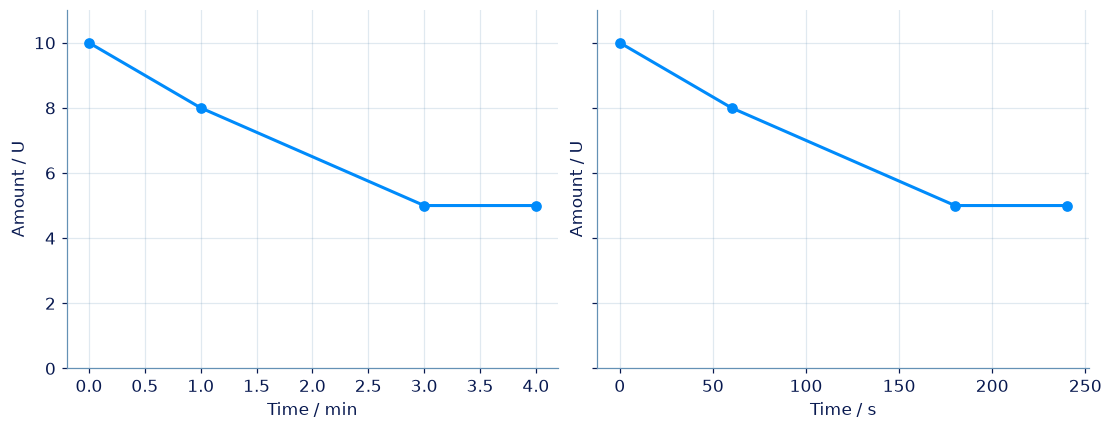

In [2]:
import numpy as np
converted = np.array(times_min, dtype=float) * 60
assert np.array_equal(converted, times_s)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, times, unit in zip(axes, [times_min, times_s], ['min', 's']):
    ax.plot(times, amounts, 'o-')
    ax.set(xlabel=f'Time / {unit}', ylabel='Amount / U', ylim=(0, 11))
plt.show()

## 对照实验

左右图的物理时刻一一对应，不能因为右图横轴数字更大，就说下降过程变慢了。再保持总量不变，只改变体积：这会怎样改变浓度？

In [3]:
volumes = [2, 3, 5]  # L
same_amounts = [6, 6, 6]  # U
concentrations = [a/v for a, v in zip(same_amounts, volumes)]
display(Markdown(show_table(['总量 / U', '体积 / L', '浓度 / (U/L)'],
                           zip(same_amounts, volumes, concentrations))))
assert np.allclose(np.array(concentrations)*np.array(volumes), same_amounts)
assert [t/60 for t in times_s] == times_min

| 总量 / U | 体积 / L | 浓度 / (U/L) |
| --- | --- | --- |
| 6 | 2 | 3 |
| 6 | 3 | 2 |
| 6 | 5 | 1.2 |

## 结果解释

两张时间图中的每个点都相同，只是横坐标单位不同。线的角度取决于坐标比例，不能脱离单位解释“快”。浓度的对照则真正改变了系统条件：体积增加而总量固定，浓度降低。

观测到总量下降，足以描述这几个时刻的变化；没有输入（input）、输出或其他观测时，尚不能唯一指定清除机制。每张图都需要变量名、单位、观察范围与来源说明。

[本章导览与各节入口](http://127.0.0.1:8000/chapters/01-01-从生理现象提出系统问题/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：换时间单位，不换总量

同一组时间序列（time series）原来以分钟记录。将时间数字乘以 factor，所追踪物质总量（tracked amount）数字保持不变，返回两个新列表。

**函数与代码模板**

```python
def solve(
    times: list[float],
    amounts: list[float],
    factor: float,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 原单位下、从早到晚的时刻。 | 原时间单位 |
| `amounts` | `list[float]` | 与每个时刻一一对应的总量。 | U |
| `factor` | `float` | 一个原时间单位等于多少个新时间单位。 | 新单位 / 原单位 |

**返回值**

按以下顺序返回元组：(converted_times, same_amounts)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `converted_times` | `list[float]` | times 中各项乘 factor。 | 新时间单位 |
| `same_amounts` | `list[float]` | 原顺序的总量。 | U |

**计算规则**

返回 (converted_times, same_amounts)；例如分钟转秒取 factor=60，分钟转小时取 1/60。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ len(times) = len(amounts) ≤ 1000；非空时 times 严格递增。
- 0 < factor ≤ 3600；时间、总量都在 0 到 10000 之间。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 原单位下、从早到晚的时刻。 | [0, 1, 3] | 原时间单位 |
| amounts | 与每个时刻一一对应的总量。 | [10, 8, 5] | U |
| factor | 一个原时间单位等于多少个新时间单位。 | 60 | 新单位 / 原单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0, 1, 3]
amounts = [10, 8, 5]
factor = 60

result = solve(times, amounts, factor)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| converted_times | times 中各项乘 factor。 | [0, 60, 180] | 新时间单位 |
| same_amounts | 原顺序的总量。 | [10, 8, 5] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 60, 180], [10, 8, 5])
```

**样例解释**

1 分钟和 60 秒是同一时刻；该时刻的总量仍为 8 U。3 分钟对应 180 秒，仍为 5 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：换时间单位，不换总量](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-time-units)

### 第 2 题 · 单项选择题：相加之前先检查单位

所追踪物质总量（tracked amount）记为 A，浓度（concentration）c = A/V，体积 V。单位分别为 U、U/L、L。以下哪个表达式的单位可以是总量？

- **A.** A + c
- **B.** A + V
- **C.** c × V
- **D.** c / V

[作答：相加之前先检查单位](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-dimension)

### 第 3 题 · 多项选择题：一条下降曲线说明什么

人工所追踪物质总量（tracked amount）序列（time series）在 0、1、2 T 为 10、8、6 U。我们尚未测量输入（input）和输出。以下哪些判断成立？

- **A.** 这些记录支持所观察时刻的总量下降。
- **B.** 仅凭这三个点，就证明只存在恒定速率清除。
- **C.** 时刻之间连接的直线可以帮助读图，但不是额外测量。
- **D.** 换成秒作横轴后，所记录的物质消失机制改变了。

[作答：一条下降曲线说明什么](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-curve-cause)

### 第 4 题 · Python 计算题：总量与浓度要分别计算

给定同一时刻几个培养孔的所追踪物质总量（tracked amount） A 和体积 V。按浓度（concentration）c = A/V 返回各孔浓度。不要先合并培养孔。

**函数与代码模板**

```python
def solve(
    amounts: list[float],
    volumes: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 各孔的总量。 | U |
| `volumes` | `list[float]` | 与总量对应的体积。 | L |

**返回值**

直接返回 concentrations（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `concentrations` | `list[float]` | 每孔的总量除以自身的体积。 | U/L |

**计算规则**

第 i 项为 amounts[i]/volumes[i]，顺序不变；空输入（input）返回空列表。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ len(amounts) = len(volumes) ≤ 1000。
- 0 ≤ amounts[i] ≤ 10000；0 < volumes[i] ≤ 1000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| amounts | 各孔的总量。 | [6, 6, 10] | U |
| volumes | 与总量对应的体积。 | [2, 3, 5] | L |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
amounts = [6, 6, 10]
volumes = [2, 3, 5]

result = solve(amounts, volumes)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| concentrations | 每孔的总量除以自身的体积。 | [3, 2, 2] | U/L |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [3, 2, 2]
```

**样例解释**

前两个孔总量都为 6 U，但体积不同，浓度分别为 3、2 U/L；总量相同不代表浓度相同。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：总量与浓度要分别计算](http://127.0.0.1:8000/chapters/01-01-%E4%BB%8E%E7%94%9F%E7%90%86%E7%8E%B0%E8%B1%A1%E6%8F%90%E5%87%BA%E7%B3%BB%E7%BB%9F%E9%97%AE%E9%A2%98/practice/?question=p01-concentration)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。